In [1]:
from datetime import datetime
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from datetime import datetime
import os
from pathlib import Path
import fsspec

import re
pd.set_option('display.max_columns', None)
sys.path.insert(0, os.path.abspath('../..'))
import repo_paths  # noqa: F401
%load_ext autoreload
%autoreload 2
from loading_runs import load_results_from_pickle, compute_rowwise_metrics

In [2]:
def give_important_features(results,
                            feature_cols=None, 
                            top_n = 10, rnd=3):

    mask_df = pd.DataFrame(
        results['mask'],
        columns=feature_cols
    )
    
    summary = (
        mask_df
        .agg(['mean', 'sem'])   # sem = std / sqrt(n)
        .T                      # features as rows
        .sort_values('mean', ascending=False)
    )
    
    print(summary.head(top_n).round(rnd))

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_tuning_lmbda(lmbda_tuning_df, y='roc_auc'):
    # Define styling constants
    fontsize_labels = 16
    fontsize_ticks = 14
    
    # Group by model_type to generate separate plots
    for model_name, group in lmbda_tuning_df.groupby('model_type'):

        if model_name == 'l2x':
            x_metric = 'num_important_features'
        elif model_name == 'lime':
            x_metric = 'epochs'
        else:
            x_metric = 'lmbda'
        
        # --- Build a DataFrame from group results ---
        df = group[[x_metric, 'accuracy', 'roc_auc', 'pr_auc','pct_sig']].copy()
        
        # --- compute integer pct_significant labels ---
        # Note: using .values or resetting index to avoid alignment issues if original indices are non-contiguous
        pct_vals = (df['pct_sig'] * 100).round().astype(int).values
        
        # --- create figure ---
        fig, ax = plt.subplots(figsize=(12, 5))
        
        # --- main line with markers ---
        sns.lineplot(
            data=df,
            x=x_metric,
            y=y,
            marker='o',
            ax=ax
        )
        
        # --- overlay scatter for % significant features ---
        sns.scatterplot(
            data=df,
            x=x_metric,
            y=y,
            s=10,
            color='black',
            label='% significant features',
            ax=ax
        )
        
        # --- numeric labels on each black dot ---
        # Using enumerate to safely index into pct_vals
        for i, (idx, row) in enumerate(df.iterrows()):
            ax.text(
                row[x_metric], 
                row[y], 
                f"{pct_vals[i]}%",
                ha='center',
                va='bottom',
                fontsize=9,
                color='black'
            )
        
        # --- axis labels, ticks, grid ---
        ax.set_title(f"Model Type: {model_name}", fontsize=fontsize_labels + 2) # Added title to distinguish plots
        ax.set_xlabel(x_metric, fontsize=fontsize_labels)
        ax.set_ylabel(y, fontsize=fontsize_labels)
        ax.tick_params(axis='both', labelsize=fontsize_ticks)
        
        ax.grid(True)
        ax.legend(fontsize=fontsize_ticks)
        
        plt.tight_layout()
        plt.show()

In [4]:
#data FYI

data = pd.read_csv('brca_small.csv', index_col=0)
X = data.values[:, :-1]
Y = data.values[:, -1]
genes = data.columns.tolist()[:-1]

## Tuning lmbda

In [5]:
val = load_results_from_pickle(folder='ICML_experiments/tcga/val',
                                        time_threshold='25_09_03_12_00_00',#"25_07_08_14_00_00",
                                        keep_run_type=None,
                                          is_output=False,
                                  is_synthetic=False)

note:
- for l2x, lmbda is meaningless. validation was across num_important_features

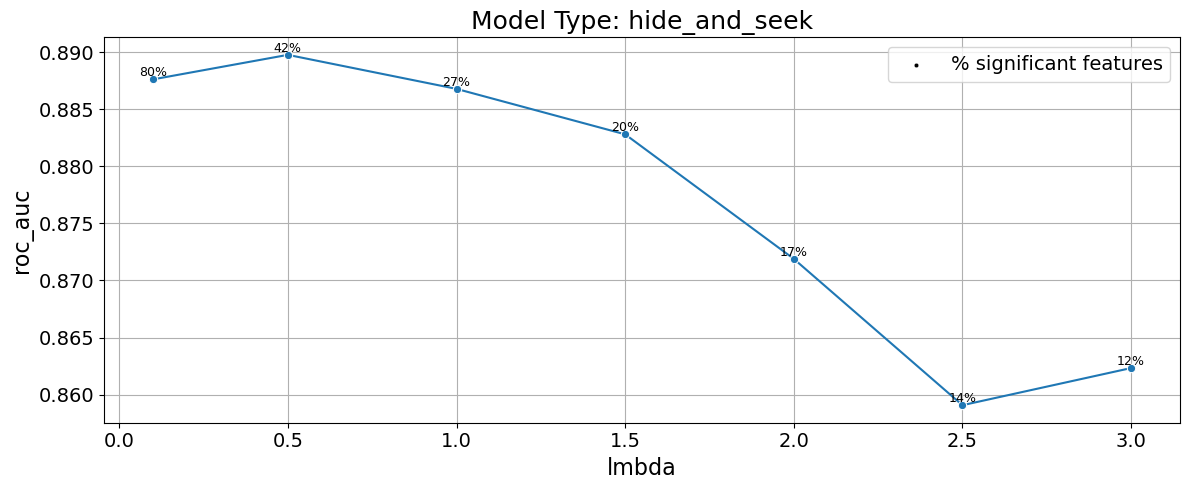

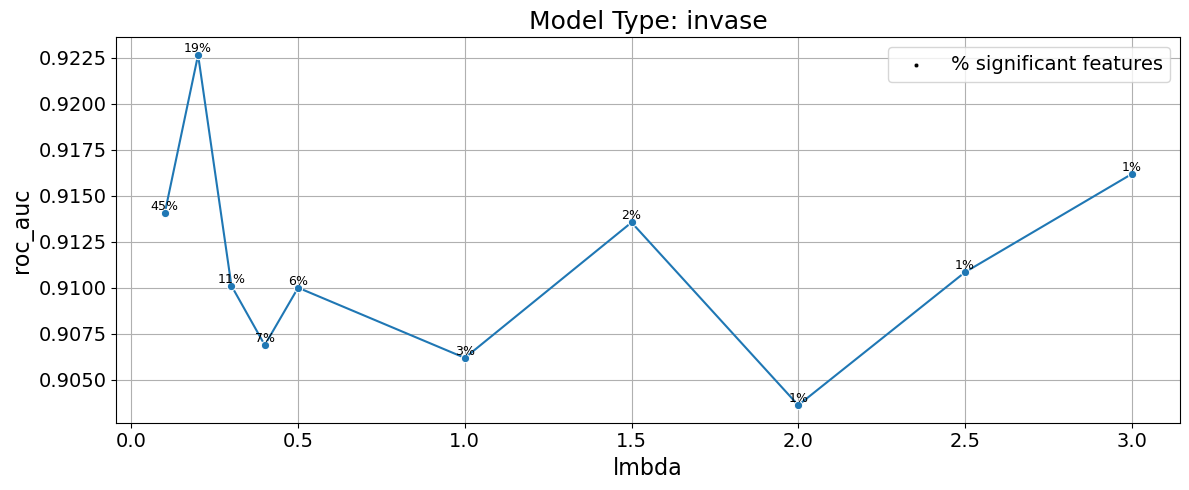

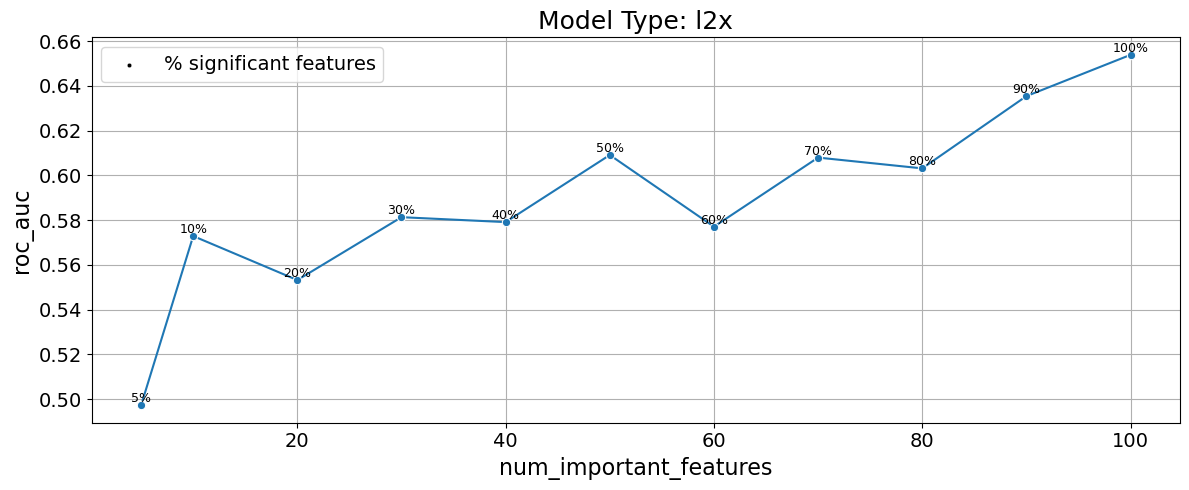

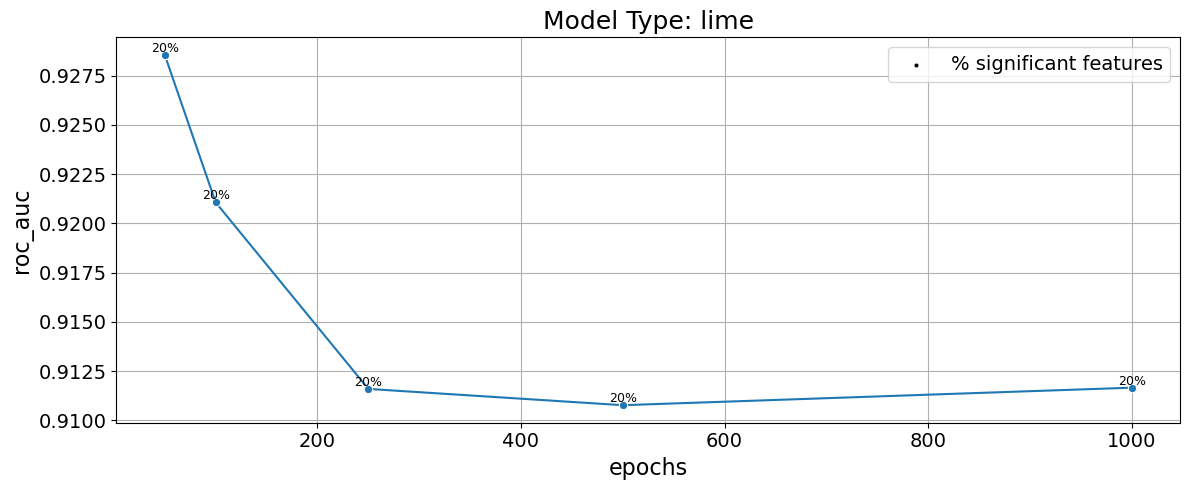

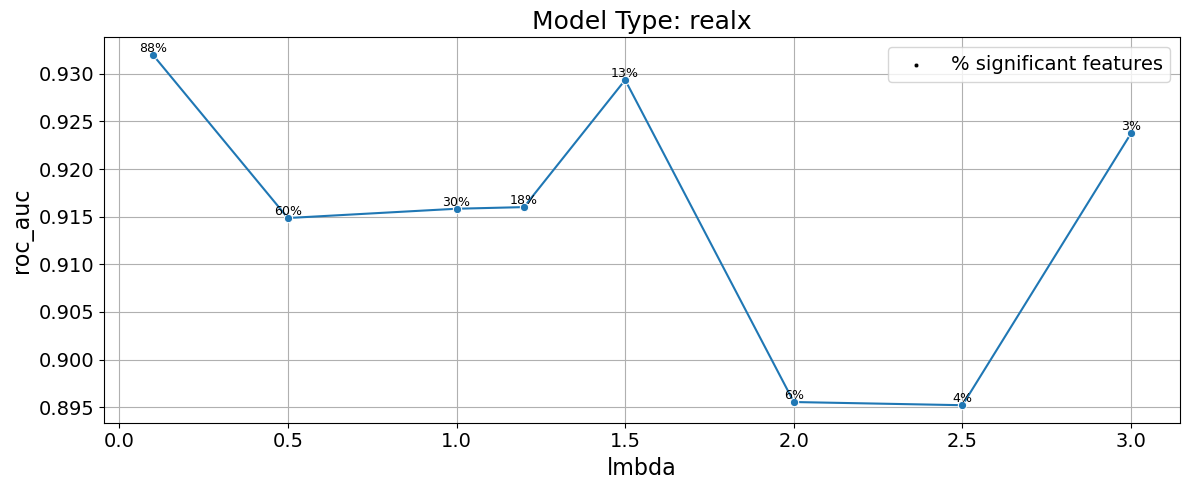

In [8]:
plot_tuning_lmbda(val, y = 'roc_auc')

In [37]:
# val.query('model_type=="invase"')[['model_type','lmbda','roc_auc']].sort_values(by='lmbda')

- hide&seek: lambda 1.5
- realx: lambda 1.5
- invase: lambda 0.2
- l2x: num_important_features 50
- lime: epochs: 50 (note that this is actually 100 epochs in implementation)

In [147]:
xgboost_val = load_results_from_pickle(folder='ICML_experiments/tcga/val/xgboost',
                                        time_threshold='25_09_03_12_00_00',#"25_07_08_14_00_00",
                                        keep_run_type=None,
                                          is_output=False,
                                  is_synthetic=False)

In [148]:
xgboost_val = xgboost_val[['roc_auc','pr_auc','xgb_params']].sort_values(by='roc_auc',ascending=False)
i = 0
xgboost_val.iloc[i], xgboost_val.iloc[i].xgb_params

(roc_auc                                                0.942767
 pr_auc                                                 0.860817
 xgb_params    {'objective': 'multi:softprob', 'eval_metric':...
 Name: 16, dtype: object,
 {'objective': 'multi:softprob',
  'eval_metric': 'mlogloss',
  'num_class': 4,
  'max_depth': 5,
  'eta': 0.03,
  'subsample': 1.0,
  'colsample_bytree': 1.0,
  'seed': 0,
  'num_boost_round': 200})

xgboost params:
- note: did search across eta, max_depth, num_boost_round
- {'objective': 'multi:softprob',
  'eval_metric': 'mlogloss',
  'num_class': 4,
  'max_depth': 5,
  'eta': 0.03,
  'subsample': 1.0,
  'colsample_bytree': 1.0,
  'seed': 0,
  'num_boost_round': 200}

## test

In [153]:
test = load_results_from_pickle(folder='ICML_experiments/tcga/test',
                                        time_threshold='25_09_03_12_00_00',#"25_07_08_14_00_00",
                                        keep_run_type=None,
                                          is_output=False,
                                  is_synthetic=False)

In [170]:
for i in range(len(test)):
    results = test.iloc[i]
    print(results['model_type'])

    give_important_features(results=results,
                                feature_cols=genes, 
                                top_n = 10, rnd=3)
    print()

hide_and_seek
          mean    sem
ESR1     0.999  0.000
CCNB2    0.951  0.014
STATH    0.827  0.018
C6orf26  0.804  0.017
TUBB     0.784  0.024
C7       0.773  0.022
NCAPH2   0.734  0.021
UPK3B    0.727  0.033
PARP1    0.710  0.036
HACE1    0.680  0.031

invase
            mean    sem
CCNB2      0.723  0.037
ESR1       0.711  0.040
ZNF775     0.680  0.039
KLF3       0.619  0.038
C6orf15    0.610  0.040
TMSB10     0.597  0.038
NCAPH2     0.586  0.032
C20orf111  0.570  0.036
NUP210     0.562  0.041
CAPZB      0.553  0.036

l2x
         mean    sem
PENK     0.64  0.048
BIRC3    0.60  0.049
TMEM52   0.59  0.049
HPS4     0.59  0.049
OTUD3    0.59  0.049
CAPZB    0.59  0.049
C6orf26  0.58  0.050
STXBP1   0.58  0.050
ACLY     0.58  0.050
COL25A1  0.58  0.050

lime
         mean    sem
TUBB     0.61  0.049
HACE1    0.55  0.050
C6orf26  0.53  0.050
CCNB2    0.52  0.050
ATP6V0C  0.49  0.050
OAS2     0.49  0.050
AYTL1    0.48  0.050
OSTbeta  0.48  0.050
C7       0.48  0.050
ESR1     0.47  0.050

not using above lime. That is just counting whether included. Below is averaging the actual weight assigned - ie more granular

lime

In [169]:
lime_results = test.query('model_type=="lime"')
assert(len(lime_results))==1
lime_explanations = lime_results.lime_explanations.iloc[0]
lime_explanations = np.abs(lime_explanations.fillna(0))
lime_explanations.columns = genes

summary = (
    lime_explanations
    .agg(['mean', 'sem'])   # sem = std / sqrt(n)
    .T                      # features as rows
    .sort_values('mean', ascending=False)
)

print(summary.head(10).round(3))

           mean    sem
TUBB      0.044  0.004
HACE1     0.044  0.005
C6orf26   0.038  0.004
PENK      0.033  0.004
ESR1      0.033  0.004
C7        0.032  0.004
CCNB2     0.031  0.003
KIAA1949  0.029  0.003
NCAPH2    0.029  0.004
OAS2      0.029  0.003
